In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_358/4162663930.py:29: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [6]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [7]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [8]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [9]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof_types.txt','rb') as f:
    lensing_cat=pickle.load(f)

In [10]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [11]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]
def bootstrap_lensing(gal_num_list,name,rp_bins,times=5000):
    lens_list=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        lens_tab=[]
        for i in gal_rand:
            lens_tab.append(lensing_cat[i][name])
        lens=np.mean(lens_tab,axis=0)
        lens_list.append(lens)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(lens_list).T[j],84))
        lower.append(np.percentile(np.asarray(lens_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [12]:
logrp_bins = np.linspace(-1,1.5,20)
rp_bins = 10**logrp_bins
logrp_mids = 0.5*(logrp_bins[:-1] + logrp_bins[1:])

In [13]:
mask1=(tab2['c_200c']<15)

In [14]:
mpeak_hist=[[],]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        print(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

1036
1758
2015
2085
2245
3025
3243


In [15]:
age_tab[mpeak_hist[0][0]]

array([0.37 , 0.418, 0.475, 0.517, 0.547, 0.596, 0.64 , 0.687, 0.732,
       0.764, 0.844, 0.932, 0.965, 1.036, 1.112, 1.177, 1.282, 1.366,
       1.466, 1.54 , 1.689, 1.812, 1.944, 2.145, 2.238, 2.384, 2.539,
       2.685, 2.839, 2.981, 3.129, 3.285, 3.447, 3.593, 3.744, 3.902,
       4.038, 4.206, 4.293, 4.502, 4.657, 4.816, 4.98 , 5.115, 5.289,
       5.431, 5.577, 5.726, 5.878, 6.073, 6.193, 6.356, 6.522, 6.692,
       6.822, 6.998, 7.132, 7.314, 7.453, 7.642, 7.786, 7.932, 8.079,
       8.28 , 8.432, 8.587, 8.743, 8.902, 9.062, 9.225, 9.389])

In [16]:
age_list=age_tab[32:73]*0.9999

In [17]:
def bootstrap_ratio_lensing(gal_num_upp,gal_num_down,name,rp_bins,times=5000):
    ratio_list=[]
    for ii in range(times):
        gal_rand_upp=resample_list(gal_num_upp)
        lens_tab=[]
        for i in gal_rand_upp:
            lens_tab.append(lensing_cat[i][name])
        lens_upp=np.mean(lens_tab,axis=0)
        gal_rand_down=resample_list(gal_num_down)
        lens_tab=[]
        for i in gal_rand_down:
            lens_tab.append(lensing_cat[i][name])
        lens_down=np.mean(lens_tab,axis=0)
        ratio_list.append(lens_down/lens_upp)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_358/3814479355.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_358/3814479355.py:44: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),


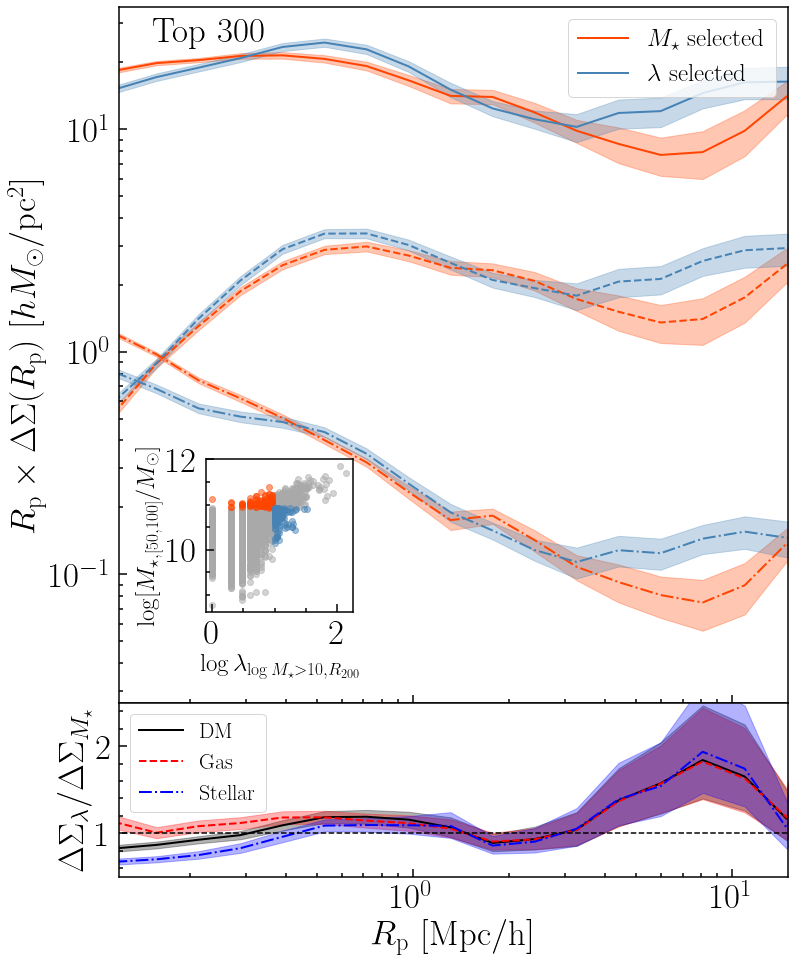

In [18]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=300
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['dm'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'dm',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['dm'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'dm',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'dm',rp_bins)


fig=plt.figure(figsize=(12,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0.15,height_ratios=(0.8,0.2))
(ax2,ax3)=gs.subplots(sharex='col')
ax1 = ax2.inset_axes([0.13, 0.13, 0.22,0.22], transform=ax2.transAxes)
ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
            np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
            c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=25)
ax1.set_xlabel(label,fontsize=25)
ax2.text(0.05,0.95,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=35)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',label=r'$M_\star$ {\rm selected}',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',label=r'$\lambda$ {\rm selected}',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm DM',color='black',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='black',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['gas'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'gas',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['gas'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'gas',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'gas',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='--',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='--',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Gas',ls='--',color='red',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='red',alpha=0.3)


up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['stellar'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['stellar'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='-.',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='-.',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Stellar',ls='-.',color='blue',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='blue',alpha=0.3)


ax2.legend(loc=1,fontsize=25)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.12,15)
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax3.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
ax3.set_ylim(0.5,2.5)
ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax3.legend(fontsize=22)


plt.savefig(fig_dir+"Fig7_x.pdf",dpi=150)

In [29]:
age_tab[[33,50,59,72]]

array([3.285, 5.878, 7.314, 9.389])